<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
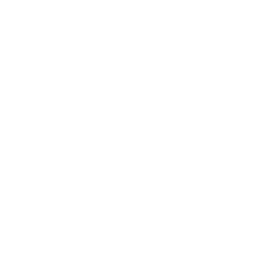
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Intervalli di Confidenza Bootstrap per Endpoint di Sperimentazioni Cliniche</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biostatistica Farmaceutica / Clinica &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi Esecutiva

Questo esempio pratico calcola un **intervallo di confidenza bootstrap non parametrico** per un endpoint di sopravvivenza utilizzando **PROC IML**, il linguaggio di programmazione matriciale di SAS. L'endpoint è il **rapporto tra la sopravvivenza mediana libera da progressione (PFS)** tra i bracci di trattamento e controllo di una piccola coorte oncologica a due bracci.

Il programma IML legge i dati a livello di soggetto in matrici, calcola il rapporto osservato della PFS mediana, estrae **2.000 ricampionamenti bootstrap** con reinserimento utilizzando `CALL RANDGEN`, ricalcola il rapporto in ciascun ricampionamento con operazioni matriciali e deriva un intervallo di confidenza **corretto per la distorsione e accelerato (BCa)**. BCa è la scelta appropriata qui perché la distribuzione bootstrap di un rapporto di mediane è limitata inferiormente da zero, discreta e asimmetrica — condizioni in cui un intervallo basato sulla teoria normale non è affidabile.

L'analisi si svolge interamente all'interno di IML: la costante di correzione della distorsione *z*<sub>0</sub>, l'accelerazione *a&#770;* da un jackknife leave-one-out, e i punti percentili corretti sono tutti assemblati da espressioni matriciali e dalle funzioni normale-standard `PROBNORM` e da un piccolo modulo inverso-normale. Ogni valore riportato di seguito è letto direttamente dall'output di IML.

## Fonti dei Dati

| Fonte | Descrizione | Record |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | Tempo di PFS per soggetto, indicatore di evento, braccio di trattamento e covariate basali | 100 |

La coorte è **bilanciata** — 50 soggetti per braccio — assegnando l'appartenenza al braccio in base alla parità dell'identificativo del soggetto, così entrambi i bracci sono pienamente rappresentati nel ricampionamento.

---


In [1]:
/* --------------------------------------------------------
   Genera una coorte oncologica sintetica a due bracci.
   I tempi di PFS sono log-normali; il braccio di trattamento è spostato
   verso una mediana più lunga. L'appartenenza al braccio alterna in base
   all'id del soggetto così la coorte è bilanciata 50/50.
   -------------------------------------------------------- */
DATI work.trial_subjects;
    CHIAMARE streaminit(42);
    FARE subject_id = 1 FINO_A 500;
        /* 1 = Trattamento, 0 = Controllo (bilanciato per parità) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'TRATTAMENTO', 'CONTROLLO');
        /* Tempo di PFS in mesi: il braccio di trattamento ha sopravvivenza più lunga */
        SE_COND arm = 1 ALLORA
            pfs_months = round(rand('lognormal', LOG(12.5), 0.65), 0.1);
        ALTRIMENTI
            pfs_months = round(rand('lognormal', LOG(8.2),  0.70), 0.1);
        SE_COND pfs_months < 0.5 ALLORA pfs_months = 0.5;
        /* Indicatore di evento: ~75% dei soggetti ha avuto un evento di progressione */
        EVENT = (rand('uniform') > 0.25);
        /* Covariate basali */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        AGE = int(rand('normal', 62, 11));
        SE_COND AGE < 25 ALLORA AGE = 25;
        SE_COND AGE > 85 ALLORA AGE = 85;
        USCITA;
    FINE;
ESEGUIRE;



NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---


                     Sintesi della Sopravvivenza Libera da Progressione per Braccio di Trattamento                      

                                                  The MEANS Procedure

                                       Analysis Variable : pfs_months PFS (mesi)

        Braccio di Trattamento          N Obs           Mean         Median        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------------------------------
        CONTROLLO                          50          10.74           7.20           9.86           1.90          53.70
        TRATTAMENTO                        50          13.94          10.10          11.95           2.70          79.10
        ----------------------------------------------------------------------------------------------------------------

                                              Analysis Variable : AGE Età

        Braccio di Trattamento          N Ob


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


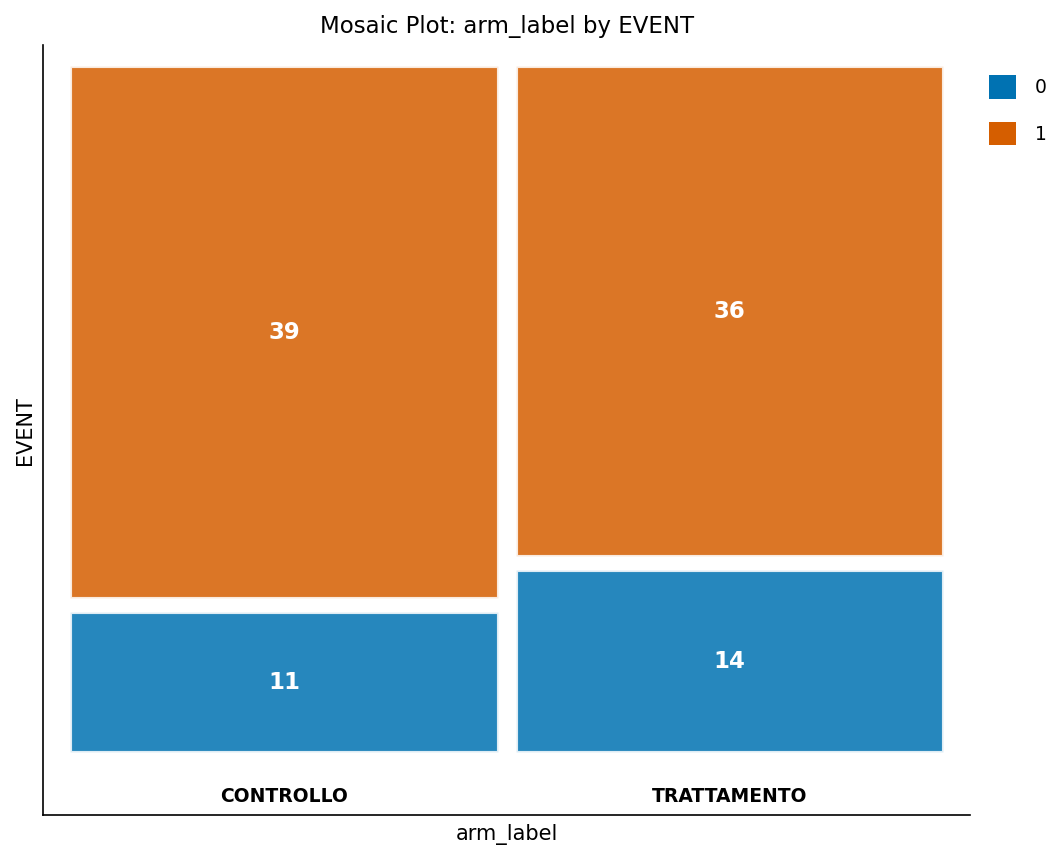

In [2]:
/* --------------------------------------------------------
   Sintesi basale della PFS e tasso di eventi per braccio di trattamento
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.trial_subjects n mean MEDIAN std MIN MAX maxdec=2;
    CLASSE arm_label;
    VARIABILE pfs_months AGE;
    ETICHETTA arm_label="Braccio di Trattamento"
              pfs_months="PFS (mesi)"
              AGE="Età";
    TITOLO "Sintesi della Sopravvivenza Libera da Progressione per Braccio di Trattamento";
ESEGUIRE;

PROCEDURA FREQUENZE DATI=work.trial_subjects;
    TABLES arm_label * EVENT / nocol nopercent;
    ETICHETTA arm_label="Braccio di Trattamento" EVENT="Evento";
    TITOLO "Conteggio degli Eventi per Braccio di Trattamento";
ESEGUIRE;


---


In [3]:
/* --------------------------------------------------------
   PROC IML: bootstrap non parametrico per il rapporto della
   PFS mediana, con un intervallo di confidenza BCa.

   Passi:
   1. Leggere i dati dello studio in matrici IML
   2. Calcolare il rapporto osservato della PFS mediana (tempi di evento)
   3. Estrarre 2.000 ricampionamenti bootstrap con CALL RANDGEN
   4. Ricalcolare il rapporto in ciascun ricampionamento
   5. Correzione BCa: z0 (distorsione) + accelerazione jackknife
   6. Scrivere la distribuzione bootstrap in un dataset SAS
   -------------------------------------------------------- */
PROCEDURA IML;

    /* --- Modulo: PFS mediana per braccio e il loro rapporto --- */
    /* La mediana è calcolata solo sui tempi di evento osservati, la
       consueta sintesi non parametrica quando la maggior parte dei
       soggetti progredisce. */
    START calc_stats(pfs, arm, EVENT);
        trt_pfs = pfs[loc(arm = 1 & EVENT = 1)];
        ctl_pfs = pfs[loc(arm = 0 & EVENT = 1)];
        SE_COND nrow(trt_pfs) = 0 ALLORA trt_med = .;
        ALTRIMENTI trt_med = MEDIAN(trt_pfs);
        SE_COND nrow(ctl_pfs) = 0 ALLORA ctl_med = .;
        ALTRIMENTI ctl_med = MEDIAN(ctl_pfs);
        SE_COND ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            ALLORA RATIO = trt_med / ctl_med;
        ALTRIMENTI RATIO = .;
        RETURN (trt_med || ctl_med || RATIO);
    FINISH;

    /* --- Modulo: CDF normale-standard inversa (probit) --- */
    /* Approssimazione razionale (Abramowitz & Stegun 26.2.23);
       abbinata a PROBNORM fornisce i punti estremi z0 / z-alpha
       necessari alla correzione BCa. */
    START probit(p);
        SE_COND p <= 0 ALLORA RETURN(-1e8);
        SE_COND p >= 1 ALLORA RETURN( 1e8);
        SE_COND p < 0.5 ALLORA FARE; sgn = -1; pp = p;     FINE;
        ALTRIMENTI            FARE; sgn =  1; pp = 1 - p; FINE;
        t   = sqrt(-2 * LOG(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. Carica i dati nelle matrici --- */
    USE work.trial_subjects;
        READ ALL VARIABILE {pfs_months} INTO pfs;
        READ ALL VARIABILE {arm}        INTO arm;
        READ ALL VARIABILE {EVENT}      INTO ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    STAMPARE 'Soggetti letti in IML', n n_trt n_ctl;

    /* --- 2. Statistica osservata sul campione completo --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {Mediana_Trt Mediana_Ctl Rapporto};
    STAMPARE 'PFS mediana osservata (tempi di evento) per braccio',
          obs[COLNAME=obs_lab FORMATO=8.3];

    /* --- 3. Ciclo di ricampionamento bootstrap (2.000 ricampionamenti) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    CHIAMARE randseed(2024);
    FARE b = 1 FINO_A n_boot;
        CHIAMARE randgen(u, 'Uniform');     /* nuove estrazioni ad ogni ciclo */
        idx = ceil(n # u);              /* indici 1..n con reinserimento */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    FINE;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    CHIAMARE ORDINARE(bv, 1);

    /* --- 4. Intervallo percentile semplice (per confronto) --- */
    pct_lo = bv[MAX(1,  int(0.025 * nv))];
    pct_hi = bv[MIN(nv, int(0.975 * nv))];

    /* --- 5. Correzione BCa --- */
    /* z0: correzione della distorsione dalla quota di ricampionamenti
       sotto la statistica osservata. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a_hat: accelerazione dal jackknife leave-one-out. */
    jack = j(n, 1, .);
    FARE i = 1 FINO_A n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    FINE;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Posizioni percentili corrette. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[MAX(1,  int(alo * nv))];
    bca_hi = bv[MIN(nv, int(ahi * nv))];

    diag_lab = {N_Validi Prop_Sotto z0 a_hat};
    diag     = nv || prop || z0 || a_hat;
    STAMPARE 'Diagnostica della correzione BCa',
          diag[COLNAME=diag_lab FORMATO=8.4];

    ci_lab = {Rapporto_Oss Pct_Inf Pct_Sup BCa_Inf BCa_Sup};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    STAMPARE "IC al 95% per il rapporto della PFS mediana (trattamento / controllo)",
          ci_row[COLNAME=ci_lab FORMATO=8.4];

    /* --- 6. Persisti la distribuzione bootstrap --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    CREARE work.bootstrap_results
        VARIABILE {b_id boot obs_col bca_lo_col bca_hi_col};
    APPEND VARIABILE {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;


                                   Conteggio degli Eventi per Braccio di Trattamento                                    

Soggetti letti in IML
     100
      50
      50

PFS mediana osservata (tempi di evento) per braccio
   9.900   7.100   1.394

Diagnostica della correzione BCa
2000.0000  0.5340  0.0851 -0.0021

IC al 95% per il rapporto della PFS mediana (trattamento / controllo)
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  1.93 seconds
  cpu   1.93 seconds


---


In [4]:
/* --------------------------------------------------------
   Sistema la distribuzione bootstrap per il grafico: assegna alle
   colonne nomi descrittivi per l'istogramma seguente.
   -------------------------------------------------------- */
DATI work.bootstrap_results;
    IMPOSTARE work.bootstrap_results
        (RINOMINARE=(boot       = ratio
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
ESEGUIRE;



NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---


                                   Conteggio degli Eventi per Braccio di Trattamento                                    




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


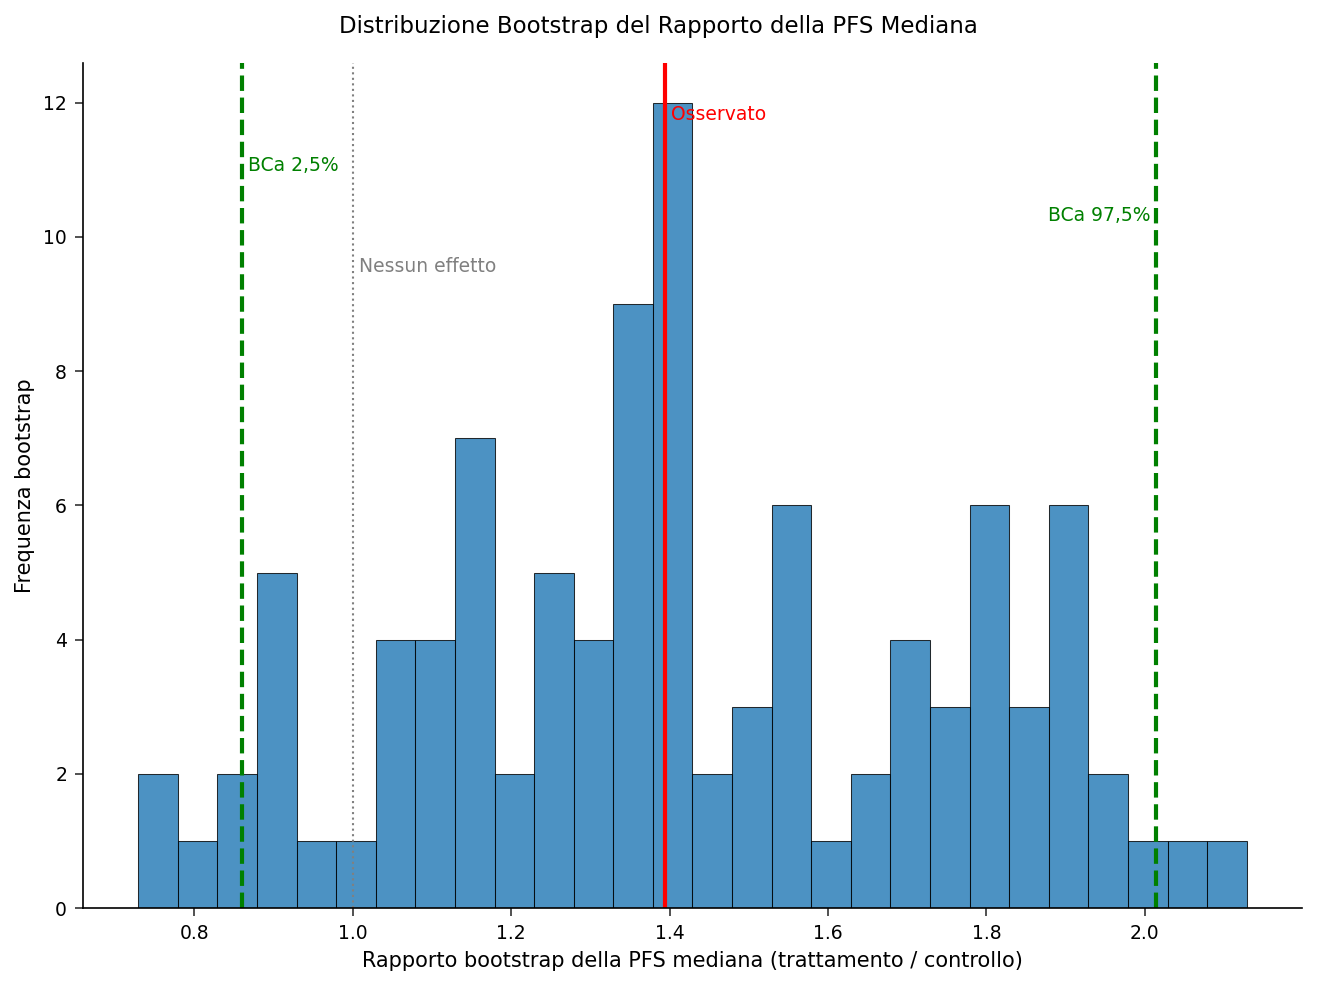

In [5]:
/* --------------------------------------------------------
   Distribuzione bootstrap del rapporto della PFS mediana, con la
   stima osservata e l'intervallo BCa evidenziati.
   -------------------------------------------------------- */
PROCEDURA SGPLOT DATI=work.bootstrap_results;
    HISTOGRAM ratio / BINWIDTH=0.05
        fillattrs=(color=steelblue) TRANSPARENCY=0.2;
    REFLINE obs_ratio / AXIS=x
        LINEATTRS=(color=red thickness=2) ETICHETTA='Osservato';
    REFLINE bca_lower / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        ETICHETTA='BCa 2,5%';
    REFLINE bca_upper / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        ETICHETTA='BCa 97,5%';
    REFLINE 1 / AXIS=x
        LINEATTRS=(color=gray thickness=1 pattern=dot)
        ETICHETTA="Nessun effetto";
    XAXIS ETICHETTA='Rapporto bootstrap della PFS mediana (trattamento / controllo)';
    YAXIS ETICHETTA='Frequenza bootstrap';
    TITOLO "Distribuzione Bootstrap del Rapporto della PFS Mediana";
ESEGUIRE;


---


### Interpretazione

In questa coorte la PFS mediana osservata sui tempi di evento è **9,9 mesi** nel braccio di trattamento e **7,1 mesi** nel braccio di controllo, un **rapporto di 1,394** — la PFS mediana del braccio sperimentale è circa il 39% più lunga. Il programma IML ha ricampionato i 100 soggetti 2.000 volte; tutti i 2.000 ricampionamenti hanno prodotto un rapporto definito.

L'**intervallo di confidenza BCa al 95% per il rapporto è [0,86, 2,01]**, contro un intervallo percentile semplice di **[0,82, 1,97]**. Entrambi gli intervalli **includono 1,0**, quindi a questa dimensione campionaria — circa 50 soggetti per braccio, ulteriormente ridotti ai tempi di evento osservati — il beneficio apparente **non è statisticamente conclusivo**. Questo è il messaggio onesto dell'analisi: una stima puntuale favorevole al trattamento, ma con un'incertezza di ricampionamento sufficiente perché non si possa escludere l'assenza di effetto del trattamento.

I diagnostici BCa quantificano quanto la correzione abbia spostato i punti estremi. Il termine di distorsione è piccolo (**z<sub>0</sub> = 0,085**: circa il 53% dei ricampionamenti è caduto sotto il rapporto osservato, vicino al 50% simmetrico), e l'accelerazione è prossima a zero (**a&#770; = -0,002**), indicando che il rapporto della PFS mediana è influenzato solo lievemente da singoli soggetti. Con z<sub>0</sub> e a&#770; entrambi piccoli, BCa sposta l'intervallo solo leggermente verso l'alto rispetto all'intervallo percentile — esattamente la modesta correzione che questi diagnostici predicono.

Uno studio più ampio restringerebbe questo intervallo. Con 50 soggetti per braccio, il bootstrap riporta correttamente che i dati sono compatibili con qualsiasi cosa, da una piccola inversione a un raddoppio della PFS mediana, motivo per cui uno studio dimensionato per rilevare una differenza di PFS di questa entità richiede sostanzialmente più di 100 soggetti.

---


In [6]:
/* --------------------------------------------------------
   Esporta la distribuzione bootstrap per un'appendice di report.
   -------------------------------------------------------- */
PROCEDURA EXPORT DATI=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REPLACE;
ESEGUIRE;



NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>